# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [3]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_464/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_464/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

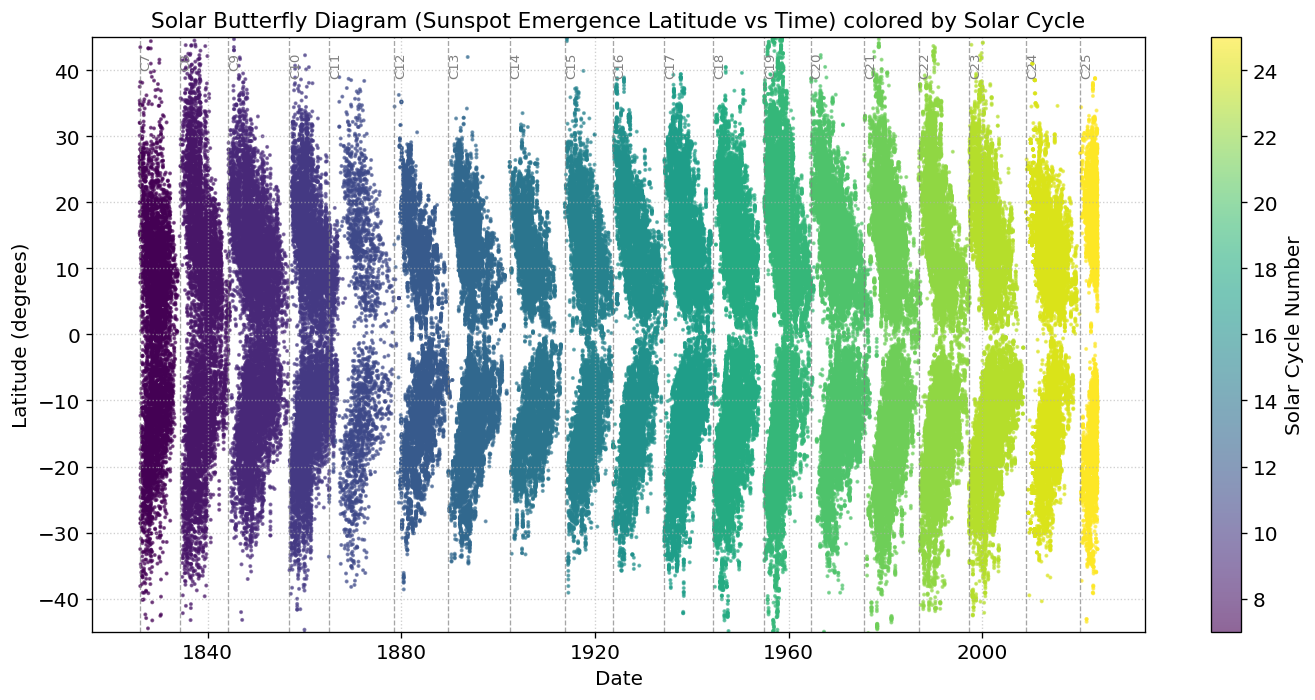

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data: filter out NaNs in 'CYCLE' and convert to integer
df_plot = df[df['CYCLE'].notna()].copy()
df_plot['CYCLE'] = df_plot['CYCLE'].astype(int)

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot, colored by solar cycle
scatter = ax.scatter(
    df_plot["date"],
    df_plot["latitude"],
    s=2,
    c=df_plot["CYCLE"],  # Color by cycle number
    cmap='viridis',     # Use a colormap to represent different cycles
    alpha=0.6
)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) colored by Solar Cycle")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
plt.grid(True, linestyle=':', alpha=0.6)

# Add a colorbar to explain the cycle colors
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Solar Cycle Number')

# Add solar cycle start lines (retaining this from the previous modification)
# Get the earliest date for each solar cycle from the *original* df to ensure all cycles are covered
cycle_starts = df[df['CYCLE'].notna()].groupby('CYCLE')['date'].min()

for cycle_num, start_date in cycle_starts.items():
    ax.axvline(start_date, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    # Add cycle number as text label, adjusting position for clarity
    ax.text(start_date, ax.get_ylim()[1] * 0.95, f'C{int(cycle_num)}',
            rotation=90, va='top', ha='left', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


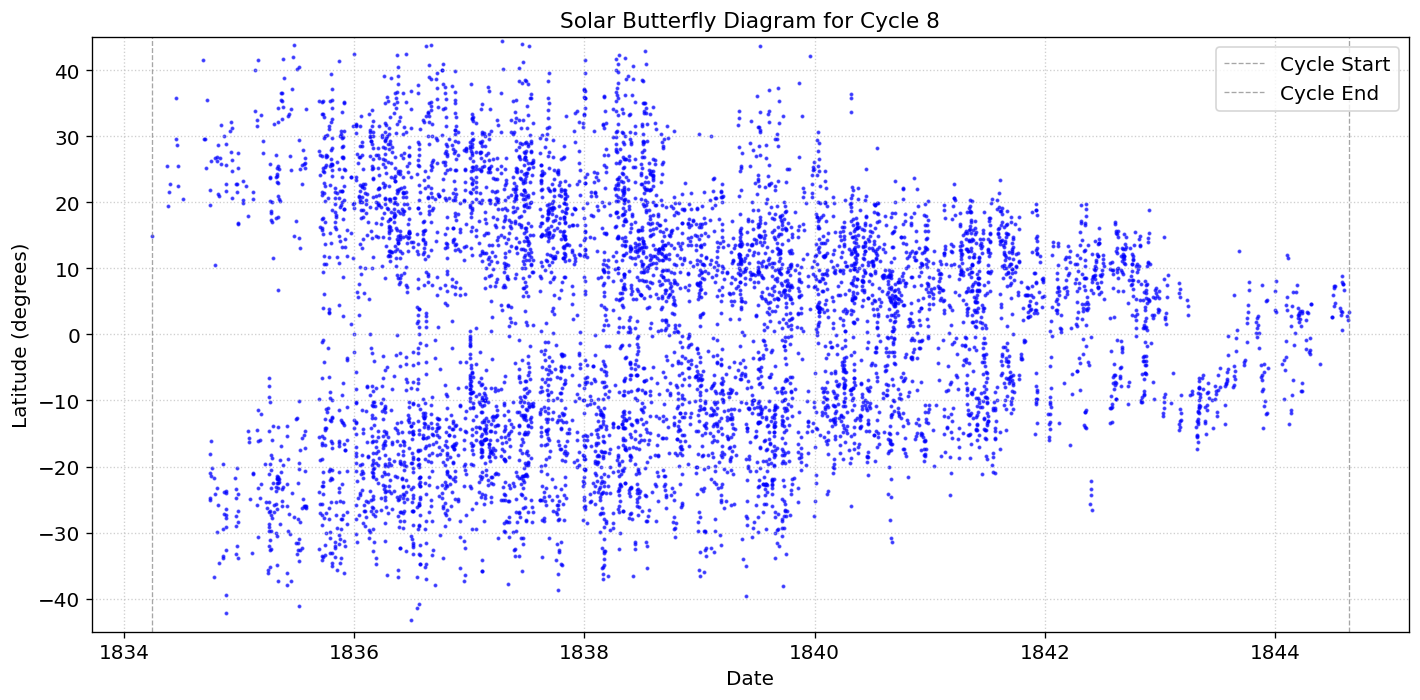

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure pandas is imported if not already, as df and df_plot are pandas DataFrames
import pandas as pd

# Check if 'df' (the main dataframe) is defined from previous cells.
# If not, print an error and stop execution, prompting the user to run the data loading cell.
if 'df' not in locals():
    print("Error: The 'df' (main dataframe) is not defined. Please ensure you have run the 'Load the Sunspot Group Catalog' cell (cell bf457f65) before this one.")
else:
    # Prepare the data for plotting: filter out NaNs in 'CYCLE' and convert to integer.

    # to resolve the NameError 'df_plot' not defined, assuming 'df' is available.
    df_plot = df[df['CYCLE'].notna()].copy()
    df_plot['CYCLE'] = df_plot['CYCLE'].astype(int)

    # --- User-definable: Choose the solar cycle to visualize ---
    specified_cycle = 8  # You can change this to any integer solar cycle number (e.g., 23, 24, 25)

    # Filter the data for the specified solar cycle
    df_single_cycle = df_plot[df_plot['CYCLE'] == specified_cycle].copy()

    if df_single_cycle.empty:
        print(f"No data found for Solar Cycle {specified_cycle}. Please choose another cycle.")
    else:
        fig, ax = plt.subplots(figsize=(12, 6))

        # Scatter plot for the single solar cycle
        ax.scatter(
            df_single_cycle["date"],
            df_single_cycle["latitude"],
            s=2,
            color='blue',
            alpha=0.6
        )

        ax.set_title(f"Solar Butterfly Diagram for Cycle {specified_cycle}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Latitude (degrees)")
        ax.set_ylim(-45, 45)
        plt.grid(True, linestyle=':', alpha=0.6)


        cycle_start = df_single_cycle['date'].min()
        cycle_end = df_single_cycle['date'].max()
        ax.axvline(cycle_start, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Cycle Start')
        ax.axvline(cycle_end, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Cycle End')
        ax.legend()

        plt.tight_layout()
        plt.show()

Just visually, we can see that cylce 8 is far more spread out. The Latitude "reach" is numch higher, reaching up to 45 degrees, while Cycle 24, they make it a little above 30 degrees.

In you look at a specific date, there are only a couple dots in cycle 24, but in cycle 8 you see many more dots. Cycle 8 has a higher vertical density.

However, if we want to make accurate comparisons, I wanted to see if there is a mathmatical way to compare the 2 cycles.

I asked AI, if it was possible to calculate the area of the wings to compare the ampltidues, and the code below compares cyles 8 and 24 mathmatically.

In [16]:
import pandas as pd
import numpy as np

def calculate_cycle_metrics(df_data, cycle_number):
    # 1. Filter data for the specific cycle
    # Using 'CYCLE' column as per df_plot
    cycle_data = df_data[df_data['CYCLE'] == cycle_number].copy()

    if cycle_data.empty:
        return None

    # Ensure date is in a numeric format (like decimal years) for calculation
    if pd.api.types.is_datetime64_any_dtype(cycle_data['date']):
        cycle_data['date_numeric'] = cycle_data['date'].dt.year + cycle_data['date'].dt.dayofyear / 365.25
    else:
        cycle_data['date_numeric'] = cycle_data['date']

    # 2. Define the grid resolution (bins)
    # We use 50 bins for time and 1 degree bins for latitude
    lat_bins = np.arange(-50, 50, 1)
    time_bins = 50

    # 3. Calculate 2D Histogram
    # This creates a matrix of the 'Butterfly Plot'
    hist, x_edges, y_edges = np.histogram2d(
        cycle_data['date_numeric'],
        cycle_data['latitude'],
        bins=[time_bins, lat_bins]
    )

    # 4. Calculate 'Area'
    # We count how many grid cells have at least one sunspot (hist > 0)
    occupied_bins = np.count_nonzero(hist)

    # 5. Calculate other Amplitude proxies
    total_observations = len(cycle_data)
    max_lat = cycle_data['latitude'].abs().max()
    mean_abs_lat = cycle_data['latitude'].abs().mean()

    return {
        "Cycle": cycle_number,
        "Wing Area (Bins)": occupied_bins,
        "Total Observations": total_observations,
        "Max Latitude": round(max_lat, 2),
        "Avg Latitude Reach": round(mean_abs_lat, 2)
    }

In [17]:
# --- Execution ---
# Make sure df_plot is available from previous cells
if 'df_plot' not in locals():
    print("Error: 'df_plot' is not defined. Please ensure you have run the 'Plot the Butterfly Diagram' cell (cell 49bc4796) before this one.")
else:
    cycles_to_compare = [8, 24]
    results = []

    for c in cycles_to_compare:
        # Pass df_plot to the function as it contains the 'CYCLE' column and filtered data
        metrics = calculate_cycle_metrics(df_plot, c)
        if metrics:
            results.append(metrics)

    # Display Comparison
    if results:
        results_df = pd.DataFrame(results)
        print("Mathematical Comparison of Solar Cycles:")
        print(results_df.to_string(index=False))
    else:
        print("No results to display. Check if the specified cycles have data.")

Mathematical Comparison of Solar Cycles:
 Cycle  Wing Area (Bins)  Total Observations  Max Latitude  Avg Latitude Reach
     8              2152                6856         53.08               15.66
    24              1476               12154         41.00               14.51


Matmatically, we can see that cycle 8 has a much larger wing area, with a higher max latitude and average latitude.

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


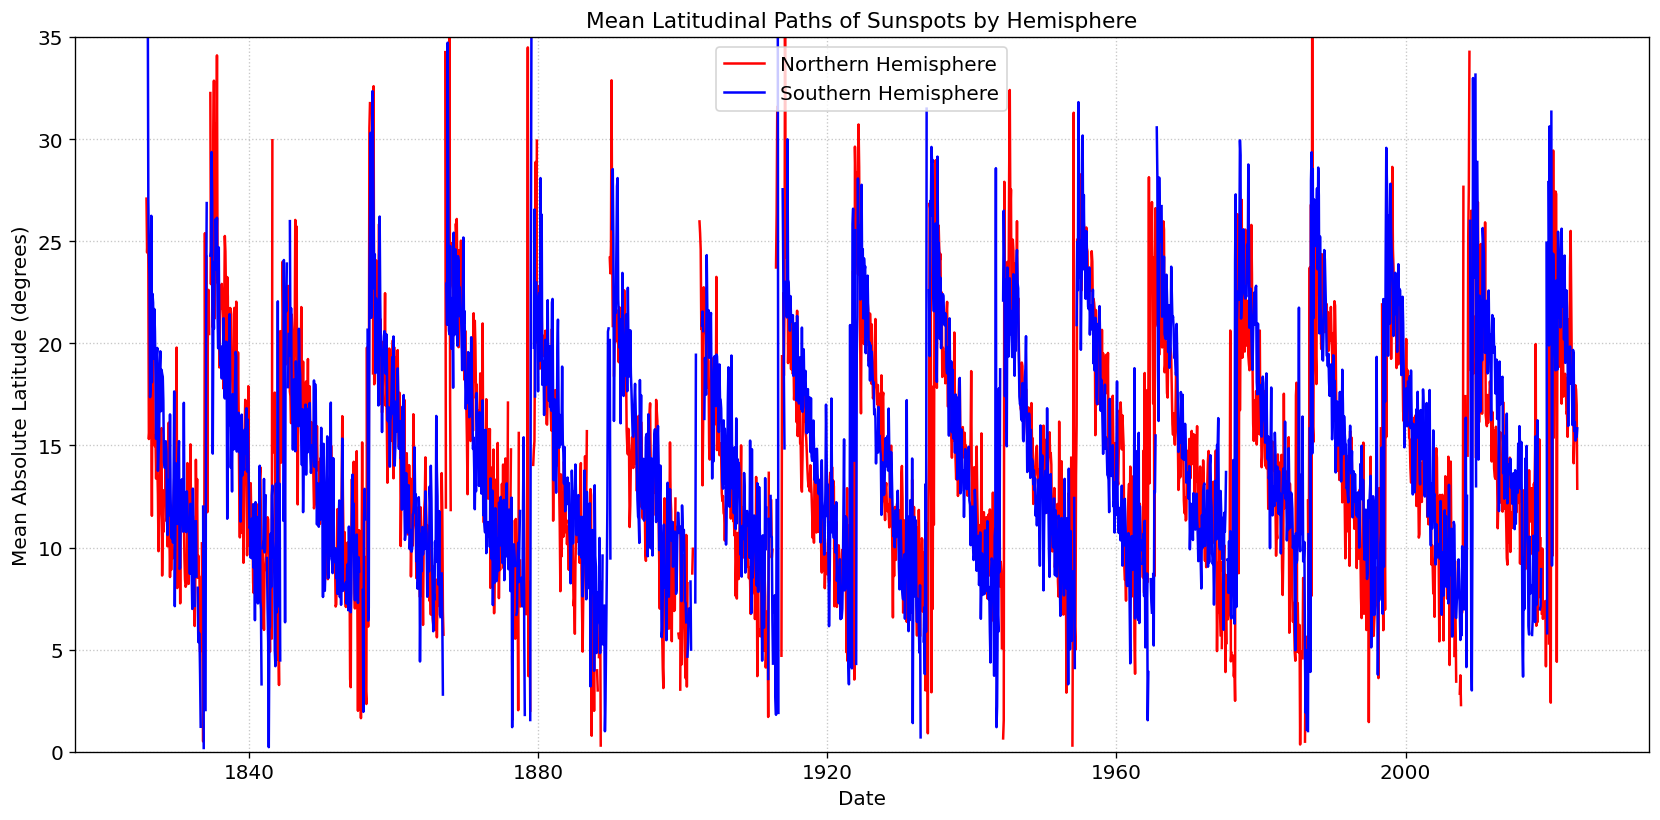

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df (the main dataframe) is available
if 'df' not in locals():
    print("Error: The 'df' (main dataframe) is not defined. Please ensure you have run the 'Load the Sunspot Group Catalog' cell (cell bf457f65) before this one.")
else:
    # Separate data into Northern and Southern Hemispheres
    df_north = df[df['latitude'] > 0].copy()
    df_south = df[df['latitude'] < 0].copy()

    # Calculate mean latitude for each month for Northern Hemisphere
    # Use 'MS' (month start) frequency to group by month
    mean_latitude_north = df_north.set_index('date')['latitude'].resample('MS').mean()

    # Calculate mean absolute latitude for each month for Southern Hemisphere
    # We take the absolute value of latitude for the southern hemisphere to visualize its path similar to the north
    mean_latitude_south = df_south.set_index('date')['latitude'].abs().resample('MS').mean()

    # Plotting the mean latitudinal paths
    fig, ax = plt.subplots(figsize=(14, 7))

    ax.plot(mean_latitude_north.index, mean_latitude_north.values, label='Northern Hemisphere', color='red', linewidth=1.5)
    ax.plot(mean_latitude_south.index, mean_latitude_south.values, label='Southern Hemisphere', color='blue', linewidth=1.5)

    ax.set_title('Mean Latitudinal Paths of Sunspots by Hemisphere')
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean Absolute Latitude (degrees)')
    ax.set_ylim(0, 35) # Set y-limit to focus on typical emergence latitudes
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()



The plot shows the sunspots when looking at the mean latitude over time for each hemisphere. Sunspots tend to emerge at higher latitudes early in a solar cycle and then progressively closer to the equator as the cycle advances.

Comparing the Northern and Southern hemispheres, we can see if there are any asymmetries in their cycle evolution, such as differences in the timing of the latitude migration or the maximum/minimum latitudes reached.

This is able to tell us the pattern that the solor cycle has. Sunspots start at higher latitudes then slowly go close to the equator as the solar cycle progresses. Each wing represents one solar cycle, which is around 11 years from peark to peak. This shows us that the movement of sunspots isn't random and shows that the suns magnetic field is changing overtime.

I wanted to learn more about how and why the sunspots migrate from poles and go closer to the equator in one solar cycle, so after doing some research I learned that the solar dynamo is what generates the magnetic fields. This is what causes the sunspots to progress closer to the equator.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


## **Reflection**

The AI recommends:

- Be specific with prompts and goals
- Define current understanding
- Break down complex topics into simpler topics
- Explain comples topics or code chunks using metaphors/analogies
- Always assk for a simplified explanation if needed


Going forward, I am going to make sure I accurately show the goal of each task, as well as define my current understanding to help AI gauge my background information. Without explaining how much I already know, AI was throwing random solar physics concepts that I wasn't familiar with. I already ask AI to break down complex topics into simpler ones, which helped me effectively understand solor cycles, sunspots, and the solor dynamo in this lesson. I also want to make sure AI explains the code its writing, so that I am able to use that to further explore solar physics, and use what I already have to devle deeper.